# 三层嵌套环形图

外层数据（原始数据）: [20, 30, 32, 37, 20, 15, 29, 10, 10, 5]
中层数据（二级分组合计）: [50, 32, 37, 35, 29, 10, 15]
内层数据（一级分组合计）: [82, 72, 54]


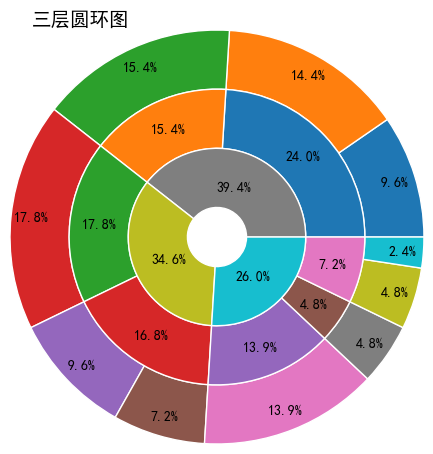

In [6]:
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.family'] = 'SimHei'

# 圆环宽度
RING_WIDTH = 0.4

# 示例数据
data = [[[20, 30], 32], [37, [20, 15]], [29, 10, [10, 5]]]

# 数据处理函数
def process_data(data):
    """
    处理嵌套数据，返回内层、中层和外层的数据列表。
    :param data: 嵌套数据
    :return: 内层数据、中层数据、外层数据
    """
    inner_data = []  # 内层数据（一级分组合计）
    middle_data = []  # 中层数据（二级分组合计）
    outer_data = []  # 外层数据（原始数据）

    for group in data:
        group_sum = 0  # 一级分组合计
        temp_middle_data = []  # 临时存储二级分组数据

        for item in group:
            if isinstance(item, list):  # 如果二级分组是列表
                group_sum += sum(item)
                temp_middle_data.append(sum(item))
                outer_data.extend(item)
            else:  # 如果二级分组是单个值
                group_sum += item
                temp_middle_data.append(item)
                outer_data.append(item)

        inner_data.append(group_sum)
        middle_data.extend(temp_middle_data)

    return inner_data, middle_data, outer_data

# 绘制圆环图
def plot_ring(data, radius, pct_distance, label=None):
    """
    绘制圆环图。
    :param data: 数据列表
    :param radius: 圆环半径
    :param pct_distance: 百分比标签距离圆心的距离
    :param label: 图例标签
    """
    plt.pie(
        data,
        radius=radius,
        autopct='%1.1f%%',
        pctdistance=pct_distance,
        wedgeprops=dict(width=RING_WIDTH, edgecolor='w'),
        labels=[label] * len(data) if label else None,
    )

# 处理数据
inner_data, middle_data, outer_data = process_data(data)

# 打印数据
print("外层数据（原始数据）:", outer_data)
print("中层数据（二级分组合计）:", middle_data)
print("内层数据（一级分组合计）:", inner_data)

# 绘制外层圆环（原始数据）
plot_ring(outer_data, radius=1.4, pct_distance=0.9)

# 绘制中层圆环（二级分组合计）
plot_ring(middle_data, radius=1.4 - RING_WIDTH, pct_distance=0.8)

# 绘制内层圆环（一级分组合计）
plot_ring(inner_data, radius=1.4 - 2 * RING_WIDTH, pct_distance=0.6)

# 设置标题
plt.title('三层圆环图', loc='left', fontsize=14, pad=20)
plt.savefig("三层环形图.png", dpi=400)
# 显示图形
plt.show()

# 设置颜色

外层数据（原始数据）: [30, 40, 50, 60, 25, 35, 45, 20, 15, 10]
中层数据（二级分组合计）: [70, 50, 60, 60, 45, 20, 25]
内层数据（一级分组合计）: [120, 120, 90]


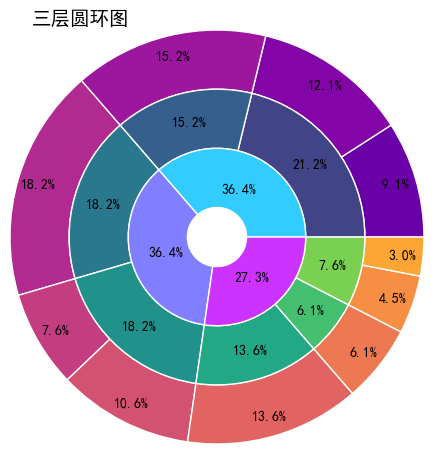

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.family'] = 'SimHei'

# 圆环宽度
RING_WIDTH = 0.4

# 示例数据
data = [
    [[30, 40], 50],  # 第一组
    [60, [25, 35]],  # 第二组
    [45, 20, [15, 10]]  # 第三组
]

# 数据处理函数
def process_data(data):
    """
    处理嵌套数据，返回内层、中层和外层的数据列表。
    :param data: 嵌套数据
    :return: 内层数据、中层数据、外层数据
    """
    inner_data = []  # 内层数据（一级分组合计）
    middle_data = []  # 中层数据（二级分组合计）
    outer_data = []  # 外层数据（原始数据）

    for group in data:
        group_sum = 0  # 一级分组合计
        temp_middle_data = []  # 临时存储二级分组数据

        for item in group:
            if isinstance(item, list):  # 如果二级分组是列表
                group_sum += sum(item)
                temp_middle_data.append(sum(item))
                outer_data.extend(item)
            else:  # 如果二级分组是单个值
                group_sum += item
                temp_middle_data.append(item)
                outer_data.append(item)

        inner_data.append(group_sum)
        middle_data.extend(temp_middle_data)

    return inner_data, middle_data, outer_data

# 绘制圆环图
def plot_ring(data, radius, pct_distance, colors, label=None):
    """
    绘制圆环图。
    :param data: 数据列表
    :param radius: 圆环半径
    :param pct_distance: 百分比标签距离圆心的距离
    :param colors: 颜色列表
    :param label: 图例标签
    """
    plt.pie(
        data,
        radius=radius,
        autopct='%1.1f%%',
        pctdistance=pct_distance,
        wedgeprops=dict(width=RING_WIDTH, edgecolor='w'),
        labels=[label] * len(data) if label else None,
        colors=colors,
        textprops={'color': 'black', 'fontsize': 10}  # 设置百分比标签的颜色和字体大小
    )

# 处理数据
inner_data, middle_data, outer_data = process_data(data)

# 打印数据
print("外层数据（原始数据）:", outer_data)
print("中层数据（二级分组合计）:", middle_data)
print("内层数据（一级分组合计）:", inner_data)

# 生成渐变色
def generate_colors(n, colormap='viridis', start=0.2, end=0.8):
    """
    生成渐变色列表，避免生成过深的颜色。
    :param n: 颜色数量
    :param colormap: 颜色映射名称
    :param start: 颜色映射起始位置（0到1之间）
    :param end: 颜色映射结束位置（0到1之间）
    :return: 颜色列表
    """
    cmap = plt.get_cmap(colormap)
    return [cmap(i) for i in np.linspace(start, end, n)]

# 生成颜色
outer_colors = generate_colors(len(outer_data), 'plasma', start=0.2, end=0.8)
middle_colors = generate_colors(len(middle_data), 'viridis', start=0.2, end=0.8)
inner_colors = generate_colors(len(inner_data), 'cool', start=0.2, end=0.8)

# 绘制外层圆环（原始数据）
plot_ring(outer_data, radius=1.4, pct_distance=0.9, colors=outer_colors)

# 绘制中层圆环（二级分组合计）
plot_ring(middle_data, radius=1.4 - RING_WIDTH, pct_distance=0.8, colors=middle_colors)

# 绘制内层圆环（一级分组合计）
plot_ring(inner_data, radius=1.4 - 2 * RING_WIDTH, pct_distance=0.6, colors=inner_colors)

# 设置标题
plt.title('三层圆环图', loc='left', fontsize=14, pad=20)

# 显示图形
plt.show()